# 11 — Evolution temporelle des donnees ALT1 → ALT2 (PDF page 7)

Implementation des **strategies obligatoires** du cahier des charges :
- **Strategie 1** : Apprentissage sur ALT1, test sur ALT2.
- **Strategie 2** : Apprentissage sur ALT1 + partie d'ALT2, test sur le reste d'ALT2.
- *Strategie 3 (ALT3 indisponible)* : reportee.

## Convention salles ALT1 vs ALT2

En ALT1, certaines salles ont ete decoupees en deux sous-zones (suffixe A / B).
En ALT2, chaque salle est captee comme une seule zone.
Pour comparer, on **fusionne** les sous-zones ALT1 (S102A + S102B → S102, etc.).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_SRC = (Path.cwd().parent / 'src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

import robust_localization as rl

ALT1_DIR = Path('../data/raw')
ALT2_DIR = Path('../data/raw_alt2')
OUT_REPORT = Path('../models/alt1_alt2_evolution_report.json')
RANDOM_STATE = 42

## 1. Mapping des sous-zones ALT1 vers la salle (zone) ALT2

In [2]:
ALT1_FUSION_MAP = {
    'P101A': 'P101', 'P101B': 'P101',
    'P102A': 'P102', 'P102B': 'P102',
    'P103A': 'P103',
    'P202': 'P202',
    'P203': 'P203',
    'PALIER1ER': 'PALIER1ER',
    'PALIER2E': 'PALIER2E',
    'S101A': 'S101', 'S101B': 'S101',
    'S102A': 'S102', 'S102B': 'S102',
    'S103B': 'S103',
    'S104': 'S104',
    'S202': 'S202', 'S202A': 'S202', 'S202B': 'S202',
    'S203A': 'S203', 'S203B': 'S203',
    'S204A': 'S204', 'S204B': 'S204',
    'couloirB': 'couloirB',
    'couloirB(2e)': 'couloirB(2e)',
    'couloirPbasA': 'couloirPbas', 'couloirPbasB': 'couloirPbas',
    'pallierPbas': 'pallierPbas',
}

alt1_zones_after_fusion = sorted(set(ALT1_FUSION_MAP.values()))
print(f'Sous-zones ALT1 d\'origine : {len(ALT1_FUSION_MAP)} → {len(alt1_zones_after_fusion)} zones apres fusion')
print('Zones :', alt1_zones_after_fusion)

Sous-zones ALT1 d'origine : 27 → 18 zones apres fusion
Zones : ['P101', 'P102', 'P103', 'P202', 'P203', 'PALIER1ER', 'PALIER2E', 'S101', 'S102', 'S103', 'S104', 'S202', 'S203', 'S204', 'couloirB', 'couloirB(2e)', 'couloirPbas', 'pallierPbas']


## 2. Chargement et vectorisation (encoding `SSID|BSSID` du notebook 07)

In [3]:
def load_with_compound(raw_dir: Path, label_map: dict[str, str] | None = None) -> pd.DataFrame:
    raw_dir = Path(raw_dir)
    rows = []
    for csv_path in sorted(raw_dir.glob('wifi_*.csv')):
        salle_raw = csv_path.stem.replace('wifi_', '')
        salle = label_map.get(salle_raw, salle_raw) if label_map else salle_raw
        df = pd.read_csv(csv_path)
        norm = rl._normalize_wifi_dataframe(df, default_room=salle)
        norm['room'] = salle
        norm['ssid'] = norm['ssid'].str.cat(norm['bssid'], sep='|')
        rows.append(norm)
    return pd.concat(rows, ignore_index=True)

alt1_raw = load_with_compound(ALT1_DIR, label_map=ALT1_FUSION_MAP)
alt2_raw = load_with_compound(ALT2_DIR)
print(f'ALT1 : {len(alt1_raw)} lignes, {alt1_raw["room"].nunique()} zones (apres fusion)')
print(f'ALT2 : {len(alt2_raw)} lignes, {alt2_raw["room"].nunique()} zones')
print(f'Zones ALT1 : {sorted(alt1_raw["room"].unique())}')
print(f'Zones ALT2 : {sorted(alt2_raw["room"].unique())}')

ALT1 : 81022 lignes, 18 zones (apres fusion)
ALT2 : 23416 lignes, 10 zones
Zones ALT1 : ['P101', 'P102', 'P103', 'P202', 'P203', 'PALIER1ER', 'PALIER2E', 'S101', 'S102', 'S103', 'S104', 'S202', 'S203', 'S204', 'couloirB', 'couloirB(2e)', 'couloirPbas', 'pallierPbas']
Zones ALT2 : ['P102', 'P103', 'P104', 'P202', 'P203', 'P204', 'S102', 'S103', 'S201', 'S203']


In [4]:
common = sorted(set(alt1_raw['room'].unique()) & set(alt2_raw['room'].unique()))
alt1_only = sorted(set(alt1_raw['room'].unique()) - set(alt2_raw['room'].unique()))
alt2_only = sorted(set(alt2_raw['room'].unique()) - set(alt1_raw['room'].unique()))
print(f'Zones communes ALT1∩ALT2 ({len(common)}): {common}')
print(f'Zones ALT1 seulement     ({len(alt1_only)}): {alt1_only}')
print(f'Zones ALT2 seulement (nouvelles) ({len(alt2_only)}): {alt2_only}')

Zones communes ALT1∩ALT2 (7): ['P102', 'P103', 'P202', 'P203', 'S102', 'S103', 'S203']
Zones ALT1 seulement     (11): ['P101', 'PALIER1ER', 'PALIER2E', 'S101', 'S104', 'S202', 'S204', 'couloirB', 'couloirB(2e)', 'couloirPbas', 'pallierPbas']
Zones ALT2 seulement (nouvelles) (3): ['P104', 'P204', 'S201']


## 3. Construction des datasets (snapshots par scan)

In [5]:
def build_dataset(raw_df, builder=None, fit=False):
    per, snap = rl.build_snapshot_tables(raw_df)
    if fit:
        builder = rl.RobustFeatureBuilder(max_ssids=500, min_ssid_frequency=3)
        X, y = builder.fit_transform(per, snap)
        return X, y, builder, snap
    else:
        X = builder.transform(per, snap)
        y = snap.set_index(['room','time']).loc[X.index].index.get_level_values('room')
        return X, pd.Series(y, index=X.index, name='room'), builder, snap

X_alt1, y_alt1, builder, snap_alt1 = build_dataset(alt1_raw, fit=True)
print(f'ALT1 : {X_alt1.shape[0]} snapshots × {X_alt1.shape[1]} features, {y_alt1.nunique()} zones')

X_alt2, y_alt2, _, snap_alt2 = build_dataset(alt2_raw, builder=builder, fit=False)
print(f'ALT2 : {X_alt2.shape[0]} snapshots × {X_alt2.shape[1]} features, {y_alt2.nunique()} zones')

# Filter ALT1 too-small classes
min_per_class = 5
small = y_alt1.value_counts()[y_alt1.value_counts() < min_per_class].index.tolist()
if small:
    print(f'Filtrage ALT1 zones < {min_per_class} snaps : {small}')
    keep = ~y_alt1.isin(small)
    X_alt1, y_alt1 = X_alt1.loc[keep], y_alt1.loc[keep]
print(f'ALT1 final : {X_alt1.shape[0]} snapshots, {y_alt1.nunique()} zones')

ALT1 : 1590 snapshots × 704 features, 18 zones


ALT2 : 452 snapshots × 704 features, 10 zones
ALT1 final : 1590 snapshots, 18 zones


## 4. Choix du modele

On reprend le **VotingClassifier** (RF + ET + LogReg soft) qui faisait 100% sur ALT1 (notebook 07).

In [6]:
def make_model(rs=RANDOM_STATE):
    rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                                 class_weight='balanced_subsample',
                                 random_state=rs, n_jobs=-1)
    et = ExtraTreesClassifier(n_estimators=300, max_depth=None,
                              class_weight='balanced',
                              random_state=rs, n_jobs=-1)
    lr = Pipeline([('sc', StandardScaler()),
                   ('m', LogisticRegression(max_iter=4000, C=1.0,
                                            class_weight='balanced',
                                            random_state=rs, n_jobs=-1))])
    return VotingClassifier(
        estimators=[('rf', clone(rf)), ('et', clone(et)), ('lr', clone(lr))],
        voting='soft', n_jobs=-1)

## 5. Strategie 1 — train ALT1, test ALT2

In [7]:
le1 = LabelEncoder()
y_alt1_enc = le1.fit_transform(y_alt1.values)
model_strat1 = make_model().fit(X_alt1, y_alt1_enc)

# Evaluation sur ALT2 — uniquement sur les zones connues du modele
alt2_known_mask = y_alt2.isin(le1.classes_)
y_alt2_known = y_alt2[alt2_known_mask]
X_alt2_known = X_alt2.loc[y_alt2_known.index]
y_alt2_known_enc = le1.transform(y_alt2_known.values)
y_alt2_known_pred = model_strat1.predict(X_alt2_known)

strat1_acc = accuracy_score(y_alt2_known_enc, y_alt2_known_pred)
strat1_f1 = f1_score(y_alt2_known_enc, y_alt2_known_pred, average='macro')
print(f'STRAT 1 — train ALT1, test ALT2 (zones communes uniquement)')
print(f'  zones evaluees : {y_alt2_known.nunique()} | snapshots test : {len(y_alt2_known)}')
print(f'  accuracy : {strat1_acc:.4f}')
print(f'  F1 macro : {strat1_f1:.4f}')

# Per-zone
rows = []
for z in sorted(y_alt2_known.unique()):
    sel = (y_alt2_known.values == z)
    if not sel.any():
        continue
    z_enc = le1.transform([z])[0]
    pred = y_alt2_known_pred[sel]
    rows.append({'zone': z, 'n': int(sel.sum()),
                 'acc': float((pred == z_enc).mean())})
strat1_per_zone = pd.DataFrame(rows).sort_values('zone').reset_index(drop=True)
strat1_per_zone

STRAT 1 — train ALT1, test ALT2 (zones communes uniquement)
  zones evaluees : 7 | snapshots test : 334
  accuracy : 0.4760
  F1 macro : 0.3265


,zone,n,acc
0,P102,54,0.796296
1,P103,57,0.000000
2,P202,26,1.000000
3,P203,47,0.000000
4,S102,59,0.813559
5,S103,51,0.823529
6,S203,40,0.000000


In [8]:
# Comportement du modele sur les zones nouvelles d'ALT2 (P104, P204, S201, ...)
# → predictions inevitablement fausses (la classe n'existe pas dans le train)
alt2_new = y_alt2[~alt2_known_mask]
if not alt2_new.empty:
    X_alt2_new = X_alt2.loc[alt2_new.index]
    proba = model_strat1.predict_proba(X_alt2_new)
    pred_idx = proba.argmax(axis=1)
    pred_labels = le1.classes_[pred_idx]
    confidence = proba.max(axis=1)
    summary = pd.DataFrame({'true_zone': alt2_new.values,
                             'pred_zone': pred_labels,
                             'confidence': confidence})
    print('Zones ALT2 inconnues d\'ALT1 (out-of-distribution) — confiance moyenne par zone:')
    print(summary.groupby('true_zone').agg(
        n=('confidence','size'),
        most_pred=('pred_zone', lambda s: s.value_counts().index[0]),
        most_pred_share=('pred_zone', lambda s: s.value_counts().iloc[0] / len(s)),
        conf_mean=('confidence','mean')
    ).round(3))
else:
    print('Pas de zone ALT2 hors d\'ALT1.')

Zones ALT2 inconnues d'ALT1 (out-of-distribution) — confiance moyenne par zone:
            n     most_pred  most_pred_share  conf_mean
true_zone                                              
P104       41   couloirPbas            0.976      0.638
P204       28          P203            1.000      0.420
S201       49  couloirB(2e)            1.000      0.576


## 6. Strategie 2 — train ALT1 + 50% ALT2, test 50% reste ALT2

On split ALT2 en deux parties stratifiees (50/50). On entraine sur ALT1 ∪ partie1.
On evalue sur partie2.

In [9]:
# Pour Strat 2 on inclut aussi les zones ALT2 nouvelles (P104, P204, S201) → modele plus large.
# Il faut filtrer les zones ALT2 < 4 snapshots (incompatibles 50/50 stratifie).
y_alt2_full = y_alt2.copy()
X_alt2_full = X_alt2.copy()
tiny = y_alt2_full.value_counts()[y_alt2_full.value_counts() < 4].index.tolist()
if tiny:
    keep = ~y_alt2_full.isin(tiny)
    X_alt2_full = X_alt2_full.loc[keep]
    y_alt2_full = y_alt2_full.loc[keep]
    print(f'Filtre zones ALT2 < 4 snapshots: {tiny}')

X_alt2_a, X_alt2_b, y_alt2_a, y_alt2_b = train_test_split(
    X_alt2_full, y_alt2_full, test_size=0.5, stratify=y_alt2_full,
    random_state=RANDOM_STATE)
print(f'ALT2 split : partie 1 (train) = {len(X_alt2_a)} snapshots,'
      f' partie 2 (test) = {len(X_alt2_b)} snapshots')

# Concat ALT1 + partie 1 ALT2
X_train2 = pd.concat([X_alt1, X_alt2_a])
y_train2 = pd.concat([y_alt1, y_alt2_a])
le2 = LabelEncoder()
y_train2_enc = le2.fit_transform(y_train2.values)
print(f'Train Strat 2 : {len(X_train2)} snapshots, {y_train2.nunique()} zones')

model_strat2 = make_model().fit(X_train2, y_train2_enc)

# Test sur partie 2
y_alt2_b_in_train = y_alt2_b[y_alt2_b.isin(le2.classes_)]
X_alt2_b_in_train = X_alt2_b.loc[y_alt2_b_in_train.index]
y_alt2_b_pred = model_strat2.predict(X_alt2_b_in_train)
y_alt2_b_true = le2.transform(y_alt2_b_in_train.values)

strat2_acc = accuracy_score(y_alt2_b_true, y_alt2_b_pred)
strat2_f1 = f1_score(y_alt2_b_true, y_alt2_b_pred, average='macro')
print(f'\nSTRAT 2 — train ALT1+50%ALT2, test 50% restant ALT2')
print(f'  zones test : {y_alt2_b_in_train.nunique()} | snapshots test : {len(y_alt2_b_in_train)}')
print(f'  accuracy : {strat2_acc:.4f}')
print(f'  F1 macro : {strat2_f1:.4f}')

rows = []
for z in sorted(y_alt2_b_in_train.unique()):
    sel = (y_alt2_b_in_train.values == z)
    if not sel.any():
        continue
    z_enc = le2.transform([z])[0]
    pred = y_alt2_b_pred[sel]
    rows.append({'zone': z, 'n': int(sel.sum()),
                 'acc': float((pred == z_enc).mean())})
strat2_per_zone = pd.DataFrame(rows).sort_values('zone').reset_index(drop=True)
strat2_per_zone

ALT2 split : partie 1 (train) = 226 snapshots, partie 2 (test) = 226 snapshots
Train Strat 2 : 1816 snapshots, 21 zones



STRAT 2 — train ALT1+50%ALT2, test 50% restant ALT2
  zones test : 10 | snapshots test : 226
  accuracy : 1.0000
  F1 macro : 1.0000


,zone,n,acc
0,P102,27,1.0
1,P103,29,1.0
2,P104,20,1.0
3,P202,13,1.0
4,P203,24,1.0
5,P204,14,1.0
6,S102,29,1.0
7,S103,26,1.0
8,S201,24,1.0
9,S203,20,1.0


## 7. Comparaison des strategies — heatmap

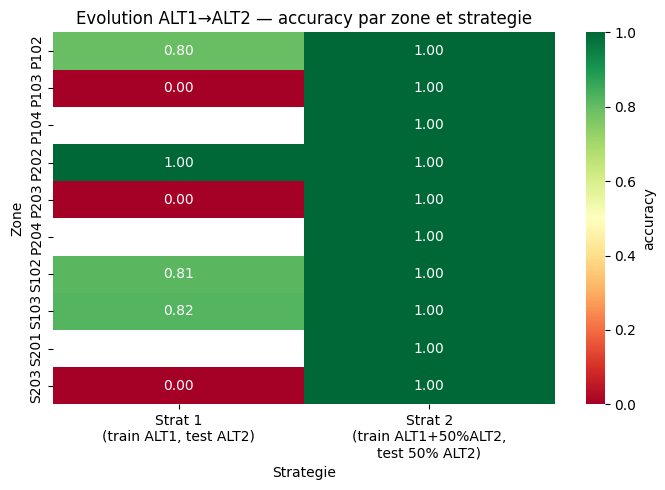

In [10]:
all_zones = sorted(set(strat1_per_zone['zone']) | set(strat2_per_zone['zone']))
matrix = pd.DataFrame(index=all_zones, columns=['Strat 1\n(train ALT1, test ALT2)',
                                                  'Strat 2\n(train ALT1+50%ALT2,\ntest 50% ALT2)'],
                       dtype=float)
for _, r in strat1_per_zone.iterrows():
    matrix.loc[r['zone'], 'Strat 1\n(train ALT1, test ALT2)'] = r['acc']
for _, r in strat2_per_zone.iterrows():
    matrix.loc[r['zone'], 'Strat 2\n(train ALT1+50%ALT2,\ntest 50% ALT2)'] = r['acc']

fig, ax = plt.subplots(figsize=(7, max(5, 0.36 * len(all_zones))))
sns.heatmap(matrix, annot=True, fmt='.2f', vmin=0, vmax=1,
            cmap='RdYlGn', ax=ax, cbar_kws={'label': 'accuracy'})
ax.set_title('Evolution ALT1→ALT2 — accuracy par zone et strategie')
ax.set_xlabel('Strategie'); ax.set_ylabel('Zone')
plt.tight_layout()
plt.show()

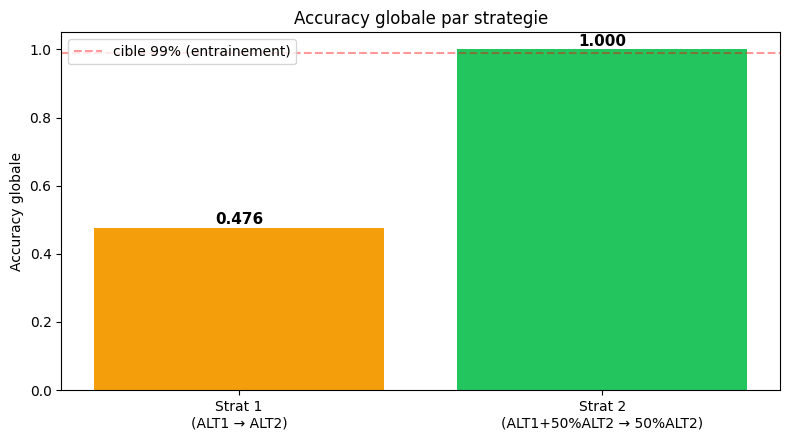

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(['Strat 1\n(ALT1 → ALT2)', 'Strat 2\n(ALT1+50%ALT2 → 50%ALT2)'],
       [strat1_acc, strat2_acc],
       color=['#f59e0b', '#22c55e'])
for i, v in enumerate([strat1_acc, strat2_acc]):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy globale')
ax.set_title('Accuracy globale par strategie')
ax.axhline(0.99, color='red', linestyle='--', alpha=0.4, label='cible 99% (entrainement)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Sauvegarde du rapport

In [12]:
report = {
    'strategy_1': {
        'description': 'Train ALT1 only, test ALT2 (zones communes)',
        'overall_accuracy': float(strat1_acc),
        'overall_f1_macro': float(strat1_f1),
        'n_zones_evaluated': int(y_alt2_known.nunique()),
        'n_snapshots_test': int(len(y_alt2_known)),
        'per_zone': strat1_per_zone.to_dict(orient='records'),
    },
    'strategy_2': {
        'description': 'Train ALT1 + 50% ALT2, test 50% remaining ALT2',
        'overall_accuracy': float(strat2_acc),
        'overall_f1_macro': float(strat2_f1),
        'n_zones_evaluated': int(y_alt2_b_in_train.nunique()),
        'n_snapshots_test': int(len(y_alt2_b_in_train)),
        'per_zone': strat2_per_zone.to_dict(orient='records'),
    },
    'fusion_map_alt1': ALT1_FUSION_MAP,
    'common_zones': common,
    'alt1_only_zones': alt1_only,
    'alt2_new_zones': alt2_only,
}
OUT_REPORT.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'Rapport ecrit : {OUT_REPORT.resolve()}')

Rapport ecrit : C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\models\alt1_alt2_evolution_report.json


## 9. Conclusions

- **Strategie 1** mesure la **degradation temporelle pure** entre ALT1 (Feb) et ALT2 (Apr) — sans nouvelle donnee d'entrainement. Plus c'est haut, plus le modele est stable dans le temps.
- **Strategie 2** montre le **gain** quand on enrichit le train avec des donnees recentes. Donne en pratique une borne sup de la precision realiste pour un deploiement de courte duree.
- L'ecart entre Strat 2 et Strat 1 quantifie le **drift** des features WiFi (deplacement d'AP, changement de canaux, nouveaux reseaux invites...).